# Data processing and Features Engineering

#### 1. Import Required Libraries

In [1]:
import glob
import pandas as pd
import numpy as np
from typing import Tuple

#### 2. Load and Explore the Dataset

In [2]:
# days to export (use a glob-friendly string like '[1-5]' to match 01..05)
days = '[1-5]'

# Build glob pattern and check matches before concatenating to avoid "No objects to concatenate"
pattern = f'/home/falih/Mastercode/Bundesliga_2023_2024/exports_per_day/tracking_data_day_0{days}.csv'
files = glob.glob(pattern)

if not files:
	raise FileNotFoundError(
		f"No files matched pattern: {pattern}. "
		"Please check the path and the available files in exports_per_day/."
	)

# Import days tracking data from CSV files
pos = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

home_team = pos['home_team_code'].unique()
print(f"Home team: {home_team}")

away_team = pos['away_team_code'].unique()
print(f"Away team: {away_team}")

match_title = pos['match_title'].unique()
# print(f"Match title: {match_title}")

Home team: ['FCB' 'RBL' 'SCF' 'M05' 'BMG' 'KOE' 'BOC' 'HDH' 'SVD' 'BVB' 'FCU' 'B04'
 'SGE' 'TSG' 'SVW' 'FCA' 'VFB' 'WOB']
Away team: ['FCA' 'VFB' 'SVW' 'SGE' 'B04' 'WOB' 'BVB' 'TSG' 'FCU' 'HDH' 'RBL' 'SVD'
 'KOE' 'FCB' 'M05' 'BOC' 'SCF' 'BMG']


#### 3. Convert Frame Numbers to Timestamps

In [3]:
def frame_to_timestamp(frame):
    frames_per_second = 25
    frames_per_minute = frames_per_second * 60
    frames_per_hour = frames_per_minute * 60

    hours = frame // frames_per_hour
    remainder = frame % frames_per_hour

    minutes = remainder // frames_per_minute
    remainder = remainder % frames_per_minute

    seconds = remainder / frames_per_second  # floating-point seconds

    return f"{hours:02d}:{minutes:02d}:{seconds:05.2f}"

# Apply the conversion to create a new 'timestamp' column
pos['timestamp'] = pos['frame'].apply(frame_to_timestamp)


#### 4. Handle Missing Values

In [4]:
# Sort by match title, frame number, and team code
pos = pos.sort_values(by=["match_title", "frame", "team_code"])

# Replace missing values in team_code and player_name with 'BALL'
pos['team_code'] = pos['team_code'].fillna('BALL')
pos['player_name'] = pos['player_name'].fillna('BALL')

# Display the first 23 rows (22 players + ball)
pos.iloc[:23]


,match_title,match_id,team_code,home_team_code,away_team_code,player_name,frame,game_section,x_position,y_position,z_position,speed,ball_status,ball_possession,timestamp
85802861,1. FC Heidenheim 1846:SV Werder Bremen,DFL-MAT-J03YES,HDH,HDH,SVW,T. Kleindienst,10000,firstHalf,-0.39,9.28,NaN,0.00,NaN,NaN,00:06:40.00
85802862,1. FC Heidenheim 1846:SV Werder Bremen,DFL-MAT-J03YES,HDH,HDH,SVW,M. Pieringer,10000,firstHalf,0.81,-9.25,NaN,0.00,NaN,NaN,00:06:40.00
85802863,1. FC Heidenheim 1846:SV Werder Bremen,DFL-MAT-J03YES,HDH,HDH,SVW,E. Dinkci,10000,firstHalf,2.99,7.99,NaN,0.00,NaN,NaN,00:06:40.00
85802864,1. FC Heidenheim 1846:SV Werder Bremen,DFL-MAT-J03YES,HDH,HDH,SVW,J.N. Beste,10000,firstHalf,7.08,-22.57,NaN,0.00,NaN,NaN,00:06:40.00
85802865,1. FC Heidenheim 1846:SV Werder Bremen,DFL-MAT-J03YES,HDH,HDH,SVW,L. Maloney,10000,firstHalf,13.86,-9.24,NaN,0.00,NaN,NaN,00:06:40.00
85802866,1. FC Heidenheim 1846:SV Werder Bremen,DFL-MAT-J03YES,HDH,HDH,SVW,N. Theuerkauf,10000,firstHalf,15.88,-17.41,NaN,0.00,NaN,NaN,00:06:40.00
85802867,1. FC Heidenheim 1846:SV Werder Bremen,DFL-MAT-J03YES,HDH,HDH,SVW,O. Traore,10000,firstHalf,21.36,7.75,NaN,0.00,NaN,NaN,00:06:40.00
85802868,1. FC Heidenheim 1846:SV Werder Bremen,DFL-MAT-J03YES,HDH,HDH,SVW,T. Siersleben,10000,firstHalf,21.65,-11.15,NaN,0.00,NaN,NaN,00:06:40.00
85802869,1. FC Heidenheim 1846:SV Werder Bremen,DFL-MAT-J03YES,HDH,HDH,SVW,J. Föhrenbach,10000,firstHalf,21.93,-24.69,NaN,0.00,NaN,NaN,00:06:40.00
85802870,1. FC Heidenheim 1846:SV Werder Bremen,DFL-MAT-J03YES,HDH,HDH,SVW,P. Mainka,10000,firstHalf,22.28,-0.19,NaN,0.00,NaN,NaN,00:06:40.00


In [5]:
# Value counts for teams and ball
pos.value_counts('team_code')

team_code
B04     5255239
FCB     5093506
VFB     4945391
SCF     4901056
BMG     4899851
SVD     4836949
WOB     4821960
HDH     4791149
SGE     4741244
KOE     4697267
RBL     4685450
BVB     4653451
FCA     4642179
TSG     4603071
BOC     4591004
SVW     4565484
M05     4544507
FCU     4495539
BALL    3907502
Name: count, dtype: int64

#### 5. Normalize Playing Direction (Left to Right ↦)

In [6]:
def flip_half_auto_by_match(half: pd.DataFrame) -> pd.DataFrame:

    if half.empty:
        return half.copy()

    flipped = half.copy()

    for match_title, group in flipped.groupby("match_title", observed=True):
        first_frames = group.nsmallest(1000, "frame")
        players_only = first_frames[first_frames["player_name"] != "BALL"]

        team_avg_x = players_only.groupby("team_code")["x_position"].mean()

        if len(team_avg_x) < 2:
            print(f"Warning: Could not identify both teams in '{match_title}'.")
            continue

        team_to_flip = team_avg_x.idxmax()

        match_mask = flipped["match_title"] == match_title
        mask_team = flipped["team_code"] == team_to_flip
        mask_ball = flipped["player_name"] == "BALL"

        flip_mask = match_mask & (mask_team | mask_ball)

        flipped.loc[flip_mask, "x_position"] *= -1

    return flipped


In [7]:
def flip_teams_to_left_to_right(df: pd.DataFrame) -> pd.DataFrame:
    first_half = df[df["game_section"] == "firstHalf"]
    second_half = df[df["game_section"] == "secondHalf"]

    flipped_first = flip_half_auto_by_match(first_half)
    flipped_second = flip_half_auto_by_match(second_half)

    return pd.concat([flipped_first, flipped_second], ignore_index=True)

flipped_df = flip_teams_to_left_to_right(pos)


#### 6. Normalization of team positions per frame

In [8]:
def normalize_team_positions_fast(df: pd.DataFrame, home_team: str, away_team: str) -> pd.DataFrame:
    df = df.copy()

    # Preserve ball rows
    ball = df[df['team_code'] == 'BALL']
    players = df[df['team_code'].isin([home_team, away_team])]

    # Per-frame & per-team mean and std
    players['x_mean'] = players.groupby(['frame', 'team_code'])['x_position'].transform('mean')
    players['y_mean'] = players.groupby(['frame', 'team_code'])['y_position'].transform('mean')

    players['x_std'] = players.groupby(['frame', 'team_code'])['x_position'].transform('std')
    players['y_std'] = players.groupby(['frame', 'team_code'])['y_position'].transform('std')

    # Handle std == 0
    players['x_std'].replace(0, 1, inplace=True)
    players['y_std'].replace(0, 1, inplace=True)

    # Normalized coordinates
    players['x_normalized'] = (players['x_position'] - players['x_mean']) / players['x_std']
    players['y_normalized'] = (players['y_position'] - players['y_mean']) / players['y_std']

    # Reattach ball rows
    result = pd.concat([players, ball], ignore_index=True)
    return result

def normalize_all_matches(df: pd.DataFrame, home_teams: list, away_teams: list) -> pd.DataFrame:
    """
    Normalize every match separately.
    Expects home_teams and away_teams lists aligned with grouped(df, "match_title").
    """
    normalized_all = []

    for (match, sub_df), home, away in zip(df.groupby("match_title"), home_teams, away_teams):
        normalized_sub = normalize_team_positions_fast(sub_df, home, away)
        normalized_all.append(normalized_sub)

    return pd.concat(normalized_all, ignore_index=True)

# Usage:
normalized_df = normalize_all_matches(flipped_df, home_team, away_team)


/tmp/ipykernel_1601065/1943353693.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  players['x_std'].replace(0, 1, inplace=True)
/tmp/ipykernel_1601065/1943353693.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

#### 7. Windows processing

In [9]:
# Helper function to process a single window
def _process_window(window_df: pd.DataFrame, window_index: int, start_time: float, end_time: float) -> pd.DataFrame | None:

    players_only = window_df[window_df["player_name"] != "BALL"]

    if players_only["player_name"].nunique() < 10:
        return None

    mode_series = window_df["ball_possession"].dropna().mode()
    dominant_team = mode_series.iloc[0] if not mode_series.empty else "UNKNOWN"

    agg = (
        players_only
        .groupby(["match_title",'match_id', "team_code", "home_team_code", "away_team_code", "player_name", "game_section"])
        .agg(
            x_norm_mean=("x_normalized", "mean"),
            y_norm_mean=("y_normalized", "mean"),
            x_norm_std=("x_normalized", "std"),
            y_norm_std=("y_normalized", "std"),
            speed_mean=("speed", "mean"),
        )
        .reset_index()
        .assign(
            window=window_index,
            dominant_possession=dominant_team,
            window_start_sec=start_time,
            window_end_sec=end_time,
            window_duration_sec=end_time - start_time,
        )
    )
    return agg

# Main function to compute normalized shapes over windows for multiple matches
def compute_normalized_shapes_multi(
    df: pd.DataFrame,
    window_size_sec: int = 30,
    max_gap_sec: float = 3,
    ts_col: str = "timestamp",
    partition_cols: Tuple[str, ...] = ("match_title",),
) -> pd.DataFrame:

    df = df.copy()
    required_cols = {
        "x_normalized","y_normalized","player_name","ball_possession",
        "speed", ts_col, "match_title","team_code","home_team_code",
        "away_team_code","game_section"
    }
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")

    # Convert timestamp to seconds (supports 'HH:MM:SS' strings or timedeltas)
    df["time_sec"] = pd.to_timedelta(df[ts_col]).dt.total_seconds()

    # Sort per partition
    df = df.sort_values(list(partition_cols) + ["time_sec"]).reset_index(drop=True)

    all_chunks = []

    for keys, part in df.groupby(list(partition_cols), sort=False, dropna=False):
        part = part.reset_index(drop=True)
        part["time_diff"] = part["time_sec"].diff().fillna(0.0)

        if part.empty:
            continue

        window_index = 0
        start_idx = 0
        start_time = part.loc[0, "time_sec"]
        n = len(part)

        for i in range(1, n):
            gap = part.loc[i, "time_diff"]
            current_time = part.loc[i, "time_sec"]
            elapsed = current_time - start_time

            # End window if elapsed > window_size OR gap > max_gap_sec
            if elapsed > window_size_sec or gap > max_gap_sec:
                window_df = part.iloc[start_idx:i]
                agg = _process_window(window_df, window_index, start_time, part.loc[i-1, "time_sec"])
                if agg is not None:
                    all_chunks.append(agg)
                    window_index += 1

                # Start next window at i
                start_idx = i
                start_time = current_time

        # Close final window
        if start_idx < n:
            window_df = part.iloc[start_idx:]
            end_time = part.iloc[-1]["time_sec"]
            agg = _process_window(window_df, window_index, start_time, end_time)
            if agg is not None:
                all_chunks.append(agg)

    return pd.concat(all_chunks, ignore_index=True) if all_chunks else pd.DataFrame()


In [10]:
df_window = compute_normalized_shapes_multi(normalized_df, window_size_sec=120, max_gap_sec=3, ts_col="timestamp")
# Show first 5 rows of window 0
df_window[df_window['window'] == 0][:5]


,match_title,match_id,team_code,home_team_code,away_team_code,player_name,game_section,x_norm_mean,y_norm_mean,x_norm_std,y_norm_std,speed_mean,window,dominant_possession,window_start_sec,window_end_sec,window_duration_sec
0,Bayer 04 Leverkusen:1. FC Heidenheim 1846,DFL-MAT-J03YEX,HDH,B04,HDH,E. Dinkci,firstHalf,0.805681,0.861498,0.042472,0.134830,13.677080,0,2.0,400.0,405.44,5.44
1,Bayer 04 Leverkusen:1. FC Heidenheim 1846,DFL-MAT-J03YEX,HDH,B04,HDH,J. Föhrenbach,firstHalf,0.574397,-1.318723,0.034401,0.040314,11.333212,0,2.0,400.0,405.44,5.44
2,Bayer 04 Leverkusen:1. FC Heidenheim 1846,DFL-MAT-J03YEX,HDH,B04,HDH,J.N. Beste,firstHalf,1.045122,-1.594333,0.080871,0.075384,15.255474,0,2.0,400.0,405.44,5.44
3,Bayer 04 Leverkusen:1. FC Heidenheim 1846,DFL-MAT-J03YEX,HDH,B04,HDH,K. Müller,firstHalf,-1.981754,0.483710,0.083679,0.126035,3.338394,0,2.0,400.0,405.44,5.44
4,Bayer 04 Leverkusen:1. FC Heidenheim 1846,DFL-MAT-J03YEX,HDH,B04,HDH,L. Maloney,firstHalf,-0.807585,0.513647,0.081412,0.110379,7.161022,0,2.0,400.0,405.44,5.44


#### Remove windows with fewer than 11 data points

In [11]:
# 1. Count rows per (match_title, team_code, window)
df_window_counts = df_window.value_counts(["match_title", "team_code", "window"])

# 2. Select combos with fewer than 11 data points
insufficient_data = df_window_counts[df_window_counts < 11]

# 3. Create list of (match_title, team_code, window) to drop
to_drop = insufficient_data.index.tolist()

# 4. Drop only those combinations
df_window = df_window[
    ~df_window.set_index(["match_title", "team_code", "window"]).index.isin(to_drop)
].reset_index(drop=True)

##### Remove short windows (< 5 seconds)

In [12]:
# 1. Identify (match_title, window) combos with duration < 5 sec
windows_to_drop = (
    df_window.loc[df_window['window_duration_sec'] < 5, ["match_title", "window"]]
    .drop_duplicates()
)

# 2. Anti-join to remove those combos
df_window = (
    df_window.merge(windows_to_drop, on=["match_title", "window"], how="left", indicator=True)
             .query("_merge == 'left_only'")
             .drop(columns="_merge")
)


In [13]:
duration = df_window.value_counts('window_duration_sec')
duration.iloc[:].sort_index

<bound method Series.sort_index of window_duration_sec
120.00    275
27.12      33
45.80      33
7.28       22
8.56       22
         ... 
101.16     11
91.24      11
108.40     11
117.36     11
120.00     11
Name: count, Length: 230, dtype: int64>

#### 8. In- and Out-of-Possession labeling

In [14]:
# Convert possession to numeric where possible
df_window['dominant_possession'] = pd.to_numeric(df_window['dominant_possession'], errors='coerce')

print(df_window['dominant_possession'].unique())
print(df_window['dominant_possession'].dtype)

# Create column indicating whether this row's team is in possession
df_window['dominant_possession_team'] = df_window.apply(
    lambda row: "In_possession" if row['dominant_possession'] == 1 and row['team_code'] == row['home_team_code']
    else "In_possession" if row['dominant_possession'] == 2 and row['team_code'] == row['away_team_code']
    else "Out_of_possession",
    axis=1
)

[2. 1.]
float64


#### 9. Remove Goalkeepers

In [15]:
def remove_goalkeepers(df_window: pd.DataFrame) -> pd.DataFrame:
    """
    Remove the goalkeeper from each (window, team) by selecting the player
    with the minimum x_norm_mean (most defensive) and removing them from the group.
    """
    result_rows = []

    for (window_id, team_code), group in df_window.groupby(['window', 'team_code']):
        # Identify goalkeeper as the player with minimal x_norm_mean
        goalkeeper_row = group.loc[group['x_norm_mean'].idxmin()]

        # Keep everyone except that goalkeeper
        filtered_group = group[group['player_name'] != goalkeeper_row['player_name']]
        result_rows.append(filtered_group)

    return pd.concat(result_rows, ignore_index=True)

df_window_no_gk = remove_goalkeepers(df_window)
df_window_no_gk['window'].value_counts().sort_index()


window
0      40
1      40
2      30
3      40
4      30
       ..
96     20
97     20
98     10
99     10
100    10
Name: count, Length: 101, dtype: int64

### 9. Team Window Grouping and Validation

In [16]:
# Team-based window grouping (each group = 10 players)
group_cols = ["match_title", "game_section", "window", "team_code"]

# Create a continuous global ID based on occurrence order (0..N-1)
df_window_no_gk["window_global"] = df_window_no_gk.groupby(group_cols, sort=False).ngroup()

# Identify window_global groups that do not contain exactly 10 rows (i.e., invalid teams)
invalid_windows = df_window_no_gk["window_global"].value_counts()
invalid_windows = invalid_windows[invalid_windows != 10]
print(invalid_windows.shape)

# Remove all invalid windows from the dataset
df = df_window_no_gk[~df_window_no_gk["window_global"].isin(invalid_windows.index)].copy()
print(f"Number of rows after removing invalid windows: {len(df)}")

# Reassign continuous window_global IDs after cleaning
df["window_global"] = df.groupby(group_cols, sort=False).ngroup()

# Preview the first rows
df.head(5)


(0,)
Number of rows after removing invalid windows: 3230


,match_title,match_id,team_code,home_team_code,away_team_code,player_name,game_section,x_norm_mean,y_norm_mean,x_norm_std,y_norm_std,speed_mean,window,dominant_possession,window_start_sec,window_end_sec,window_duration_sec,dominant_possession_team,window_global
0,Bayer 04 Leverkusen:SV Darmstadt 98,DFL-MAT-J03YEE,B04,B04,SVD,A. Grimaldo,firstHalf,0.428204,1.577054,0.373366,0.395966,8.109993,0,1.0,400.0,516.72,116.72,In_possession,0
1,Bayer 04 Leverkusen:SV Darmstadt 98,DFL-MAT-J03YEE,B04,B04,SVD,E. Palacios,firstHalf,0.116480,0.660193,0.266588,0.519510,7.015221,0,1.0,400.0,516.72,116.72,In_possession,0
2,Bayer 04 Leverkusen:SV Darmstadt 98,DFL-MAT-J03YEE,B04,B04,SVD,E. Tapsoba,firstHalf,-0.516870,1.000948,0.256741,0.209426,7.283553,0,1.0,400.0,516.72,116.72,In_possession,0
3,Bayer 04 Leverkusen:SV Darmstadt 98,DFL-MAT-J03YEE,B04,B04,SVD,F. Wirtz,firstHalf,0.831964,0.060265,0.314288,0.662831,10.976447,0,1.0,400.0,516.72,116.72,In_possession,0
4,Bayer 04 Leverkusen:SV Darmstadt 98,DFL-MAT-J03YEE,B04,B04,SVD,G. Xhaka,firstHalf,0.086827,0.120242,0.166429,0.437777,8.827211,0,1.0,400.0,516.72,116.72,In_possession,0


In [17]:
df_window_no_gk['window_global'].value_counts().sort_index()

window_global
0      10
1      10
2      10
3      10
4      10
       ..
318    10
319    10
320    10
321    10
322    10
Name: count, Length: 323, dtype: int64

#### 10. Building Team-Level Feature Aggregates per Window

In [18]:
def _compute_rf_aggregates_for_window(dfw: pd.DataFrame) -> dict:

    # Use numpy arrays for speed and handle NaNs
    x = dfw["x_norm_mean"].to_numpy()
    y = dfw["y_norm_mean"].to_numpy()

    # centroid (use nan-aggregations to be robust)
    centroid_x = float(np.nanmean(x)) if x.size else np.nan
    centroid_y = float(np.nanmean(y)) if y.size else np.nan

    # width / length of bounding box
    try:
        x_min = np.nanmin(x)
        x_max = np.nanmax(x)
        y_min = np.nanmin(y)
        y_max = np.nanmax(y)
        width = float(x_max - x_min)
        length = float(y_max - y_min)
    except ValueError:
        width = np.nan
        length = np.nan

    area = width * length if np.isfinite(width) and np.isfinite(length) else np.nan
    ratio = (width / max(length, 1e-12)) if np.isfinite(width) and np.isfinite(length) else np.nan

    # distances from centroid
    distances = np.sqrt((x - centroid_x) ** 2 + (y - centroid_y) ** 2)
    dist_mean = float(np.nanmean(distances)) if distances.size else np.nan
    dist_std = float(np.nanstd(distances, ddof=0)) if distances.size else np.nan

    # other aggregated stats (if columns present)
    x_std_mean = dfw["x_norm_std"].mean() if "x_norm_std" in dfw.columns else np.nan
    y_std_mean = dfw["y_norm_std"].mean() if "y_norm_std" in dfw.columns else np.nan
    spd_mean = dfw["speed_mean"].mean() if "speed_mean" in dfw.columns else np.nan
    dom_mean = dfw["dominant_possession"].mean() if "dominant_possession" in dfw.columns else np.nan

    return {
        "centroid_x": centroid_x,
        "centroid_y": centroid_y,
        "width": width,
        "length": length,
        "area": area,
        "ratio": ratio,
        "dist_mean": dist_mean,
        "dist_std": dist_std,
        "x_norm_std_mean": x_std_mean,
        "y_norm_std_mean": y_std_mean,
        "speed_mean_team": spd_mean,
        "dominant_possession_mean": dom_mean,
    }


def build_df_new_features_all_teams(df: pd.DataFrame) -> pd.DataFrame:

    # Validate required columns
    required_cols = {"team_code", "window_global", "dominant_possession_team"}
    if not required_cols <= set(df.columns):
        missing = required_cols - set(df.columns)
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    rows = []

    # ---- Group data by team, possession state, and time window ----
    for (team_code, pos_state, w), dfw in df.groupby(
        ["team_code", "dominant_possession_team", "window_global"], sort=True
    ):
        if dfw.empty:
            continue

        # Compute spatial & statistical aggregates for this team-window
        feats = _compute_rf_aggregates_for_window(dfw)

        # Get contextual info from the first row of the group
        first = dfw.iloc[0]
        row = {
            "team_code": team_code,
            "possession_state": pos_state,  # "In_possession" or "Out_of_possession"
            "window_global": w,
            "game_section": first.get("game_section", np.nan),
        }
        row.update(feats)
        rows.append(row)

    # ---- Safety check: ensure we produced some valid rows ----
    if not rows:
        counts = (
            df.groupby(["team_code", "dominant_possession_team", "window_global"])
            .size()
            .rename("n")
            .reset_index()
        )
        print("Debug counts per (team, state, window):")
        print(counts.head(20).to_string(index=False))
        raise ValueError("No valid (team, state, window) groups produced any rows.")

    # Sorted ONLY by global window index for chronological order
    df_new = pd.DataFrame(rows).sort_values("window_global").reset_index(drop=True)
    return df_new

# Build features now that helper is defined
df_features = build_df_new_features_all_teams(df_window_no_gk)
df_features.head()

,team_code,possession_state,window_global,game_section,centroid_x,centroid_y,width,length,area,ratio,dist_mean,dist_std,x_norm_std_mean,y_norm_std_mean,speed_mean_team,dominant_possession_mean
0,B04,In_possession,0,firstHalf,0.228297,-0.009482,1.594797,3.017854,4.812863,0.528454,0.979521,0.418870,0.303997,0.387747,8.020161,1.0
1,BMG,Out_of_possession,1,firstHalf,0.219252,-0.026154,1.746612,3.199774,5.588765,0.545855,1.006817,0.375229,0.291484,0.344829,13.862160,2.0
2,HDH,In_possession,2,firstHalf,0.198175,-0.048371,2.119073,3.091405,6.550912,0.685472,1.189616,0.335040,0.059521,0.080029,11.100277,2.0
3,SVD,Out_of_possession,3,firstHalf,0.212491,-0.021524,1.844402,3.405976,6.281987,0.541519,1.052993,0.468224,0.260898,0.281264,8.438466,1.0
4,B04,In_possession,4,firstHalf,0.243074,0.004881,1.441409,2.567802,3.701253,0.561340,0.826565,0.344645,0.281871,0.517172,9.553723,1.0


#### Save to csv

In [19]:
# save to CSV
df_window_no_gk.to_csv(f"/home/falih/Mastercode/Bundesliga_2023_2024/exports_per_day/tracking_raw_cleaned_days_{days}.csv", index=False)

In [20]:
df_features.to_csv(f"/home/falih/Mastercode/Bundesliga_2023_2024/exports_per_day/tracking_features_days_{days}.csv", index=False)

#### Correlation heatmap

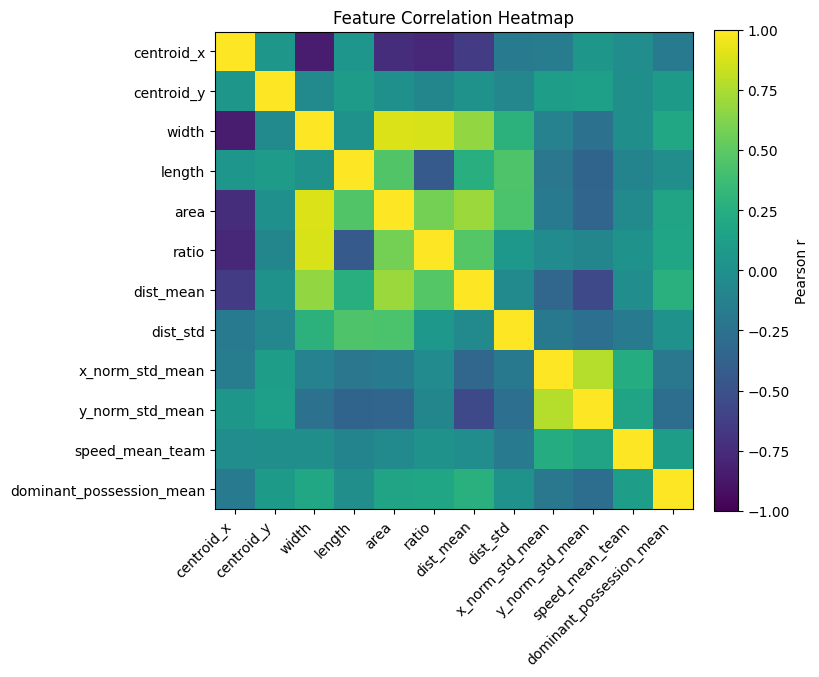

In [22]:
core_feats = [
    "centroid_x","centroid_y",
    "width","length","area","ratio",
    "dist_mean","dist_std",
    "x_norm_std_mean","y_norm_std_mean",
    "speed_mean_team","dominant_possession_mean"
]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Daten vorbereiten ---
df_feats = df_features.copy()  # aus deiner Pipeline
X = df_feats[core_feats].copy()

# Korrelation
corr = X.corr().values
labels = core_feats

# --- Plot ---
plt.figure(figsize=(8,7))
im = plt.imshow(corr, vmin=-1, vmax=1)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Pearson r")
plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(labels)), labels=labels)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()
